In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings


warnings.filterwarnings('ignore')

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
# Define file path
file_path = 'Datasets/DF_2_Crop_recommendation.csv'

try:
    # Load Data
    df = pd.read_csv(file_path)
    print("✅ Dataset Loaded Successfully!")
    print(f"📊 Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")
    
    # Show first 5 rows
    display(df.head())

except FileNotFoundError:
    print(f"❌ Error: File not found at {file_path}")
    print("Please make sure the file is in the 'Datasets' folder.")

✅ Dataset Loaded Successfully!
📊 Shape: 2200 Rows, 8 Columns


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


🔍 Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

🌱 Unique Crops (22):
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


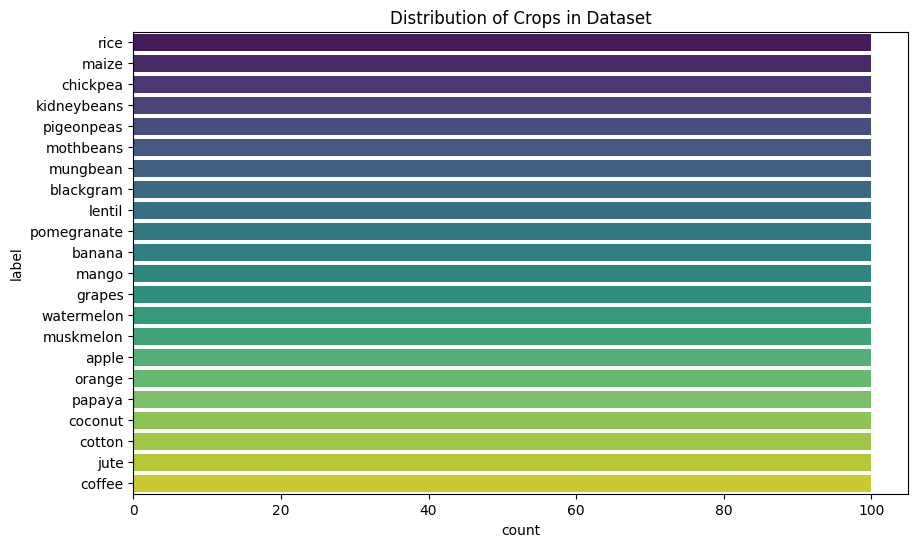

In [3]:
# Check for missing values
print("🔍 Missing Values:")
print(df.isnull().sum())

# Check unique crops
print(f"\n🌱 Unique Crops ({df['label'].nunique()}):")
print(df['label'].unique())

# Visualization: Class Distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='label', data=df, palette='viridis')
plt.title('Distribution of Crops in Dataset')
plt.show()

In [4]:
# 1. Separate Inputs (X) and Target (y)
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target = 'label'

X = df[features]
y = df[target]

# 2. Encode Target Labels (e.g., 'Rice' -> 20, 'Maize' -> 15)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 3. Split Data into Training (80%) and Testing (20%) Sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("✅ Data Preprocessing Complete")
print(f"   Training Set: {X_train.shape}")
print(f"   Test Set: {X_test.shape}")

✅ Data Preprocessing Complete
   Training Set: (1760, 7)
   Test Set: (440, 7)


In [5]:
# Initialize Random Forest Classifier
# n_estimators=100: Uses 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("⏳ Training Model...")
model.fit(X_train, y_train)
print("🚀 Model Trained Successfully!")

⏳ Training Model...
🚀 Model Trained Successfully!


🏆 Model Accuracy: 99.32%

📋 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1

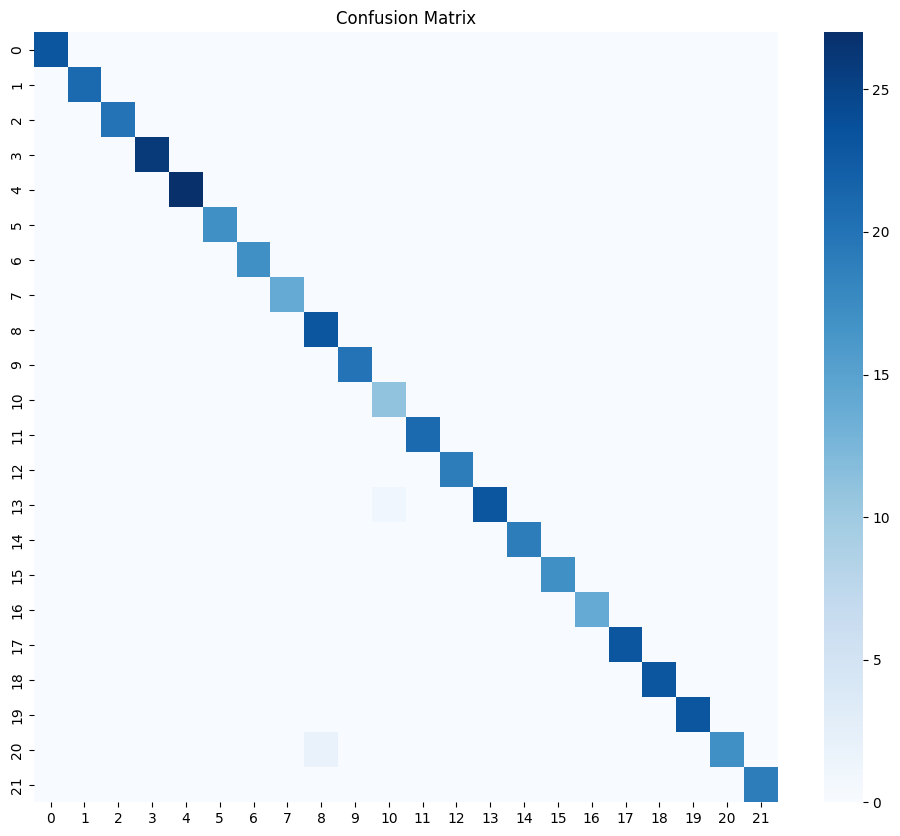

In [6]:
# Predict on Test Data
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🏆 Model Accuracy: {accuracy * 100:.2f}%")

# Detailed Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [7]:
# Example Input: High Nitrogen, High Rainfall (Should be Rice or similar)
# Values: [N, P, K, Temp, Humidity, pH, Rainfall]
sample_input = [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]]

# Predict
prediction_index = model.predict(sample_input)[0]
predicted_crop = label_encoder.inverse_transform([prediction_index])[0]

# Probability (Confidence Score)
probs = model.predict_proba(sample_input)[0]
confidence = max(probs) * 100

print(f"🌾 Input: {sample_input}")
print(f"✅ Recommended Crop: {predicted_crop}")
print(f"📊 Confidence: {confidence:.2f}%")

🌾 Input: [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]]
✅ Recommended Crop: rice
📊 Confidence: 99.00%


In [8]:
# Save Model and Label Encoder
joblib.dump(model, 'crop_recommendation_model.joblib')
joblib.dump(label_encoder, 'crop_label_encoder.joblib')

print("💾 Files Saved Successfully:")
print("   1. crop_recommendation_model.joblib")
print("   2. crop_label_encoder.joblib")

💾 Files Saved Successfully:
   1. crop_recommendation_model.joblib
   2. crop_label_encoder.joblib

👉 Please move these 2 files to your Django Project Base Directory (where manage.py is).
